# Beats & spectrogram
Extract audio → detect hits (onsets) and the tempo grid → plot, listen, export, split.

In [1]:
from fractions import Fraction
from pathlib import Path
import csv, re, subprocess
import numpy as np, librosa, librosa.display, matplotlib.pyplot as plt
from IPython.display import Audio

VIDEO = Path("welcome.mp4")
WAV = Path(VIDEO.stem + ".wav")
HOP = 128     # analysis step: 128 / 44100 ≈ 2.9 ms time resolution
DELTA = 0.07  # onset sensitivity: raise to drop weak hits, lower to catch more
SCENE = 0.3   # visual cut threshold (0–1): raise if one shot gets split, lower if real cuts are missed

subprocess.run(["ffmpeg", "-v", "error", "-y", "-i", VIDEO, "-vn", "-ac", "1", "-ar", "44100", WAV], check=True)
y, sr = librosa.load(WAV, sr=None)
rate, duration = subprocess.run(["ffprobe", "-v", "error", "-select_streams", "v:0", "-show_entries", "stream=r_frame_rate,duration",
                                 "-of", "default=nw=1:nk=1", VIDEO], capture_output=True, text=True, check=True).stdout.split()
fps, duration = float(Fraction(rate)), float(duration)  # video length; the audio track can be shorter
print(f"{len(y) / sr:.3f} s @ {sr} Hz, resolution {HOP / sr * 1000:.1f} ms")

8.012 s @ 44100 Hz, resolution 2.9 ms


In [2]:
onset_env = librosa.onset.onset_strength(y=y, sr=sr, hop_length=HOP)
tempo, beat_frames = librosa.beat.beat_track(onset_envelope=onset_env, sr=sr, hop_length=HOP)
onset_frames = librosa.onset.onset_detect(onset_envelope=onset_env, sr=sr, hop_length=HOP, delta=DELTA)

scenes = subprocess.run(["ffmpeg", "-v", "error", "-i", VIDEO, "-vf", f"select='gt(scene,{SCENE})',metadata=print:file=-", "-an", "-f", "null", "-"],
                        capture_output=True, text=True, check=True).stdout

beats = librosa.frames_to_time(beat_frames, sr=sr, hop_length=HOP)    # steady tempo grid
onsets = librosa.frames_to_time(onset_frames, sr=sr, hop_length=HOP)  # every actual hit
cuts = np.array([float(t) for t in re.findall(r"pts_time:([\d.]+)", scenes)])  # where the editor cut the video
MARKS = cuts  # what gets plotted in red, exported and split on; use `onsets` for every hit, `beats` for a steady grid
print(f"tempo ≈ {float(np.atleast_1d(tempo)[0]):.1f} BPM, {len(beats)} grid beats, {len(onsets)} onsets, {len(cuts)} cuts")
print(np.round(MARKS, 3))

tempo ≈ 93.1 BPM, 11 grid beats, 29 onsets, 24 cuts
[0.833 1.5   2.033 2.733 2.9   3.067 3.233 3.4   3.7   3.967 4.367 4.633
 4.9   5.3   5.567 5.7   5.867 6.1   6.333 6.767 6.967 7.233 7.467 7.667]


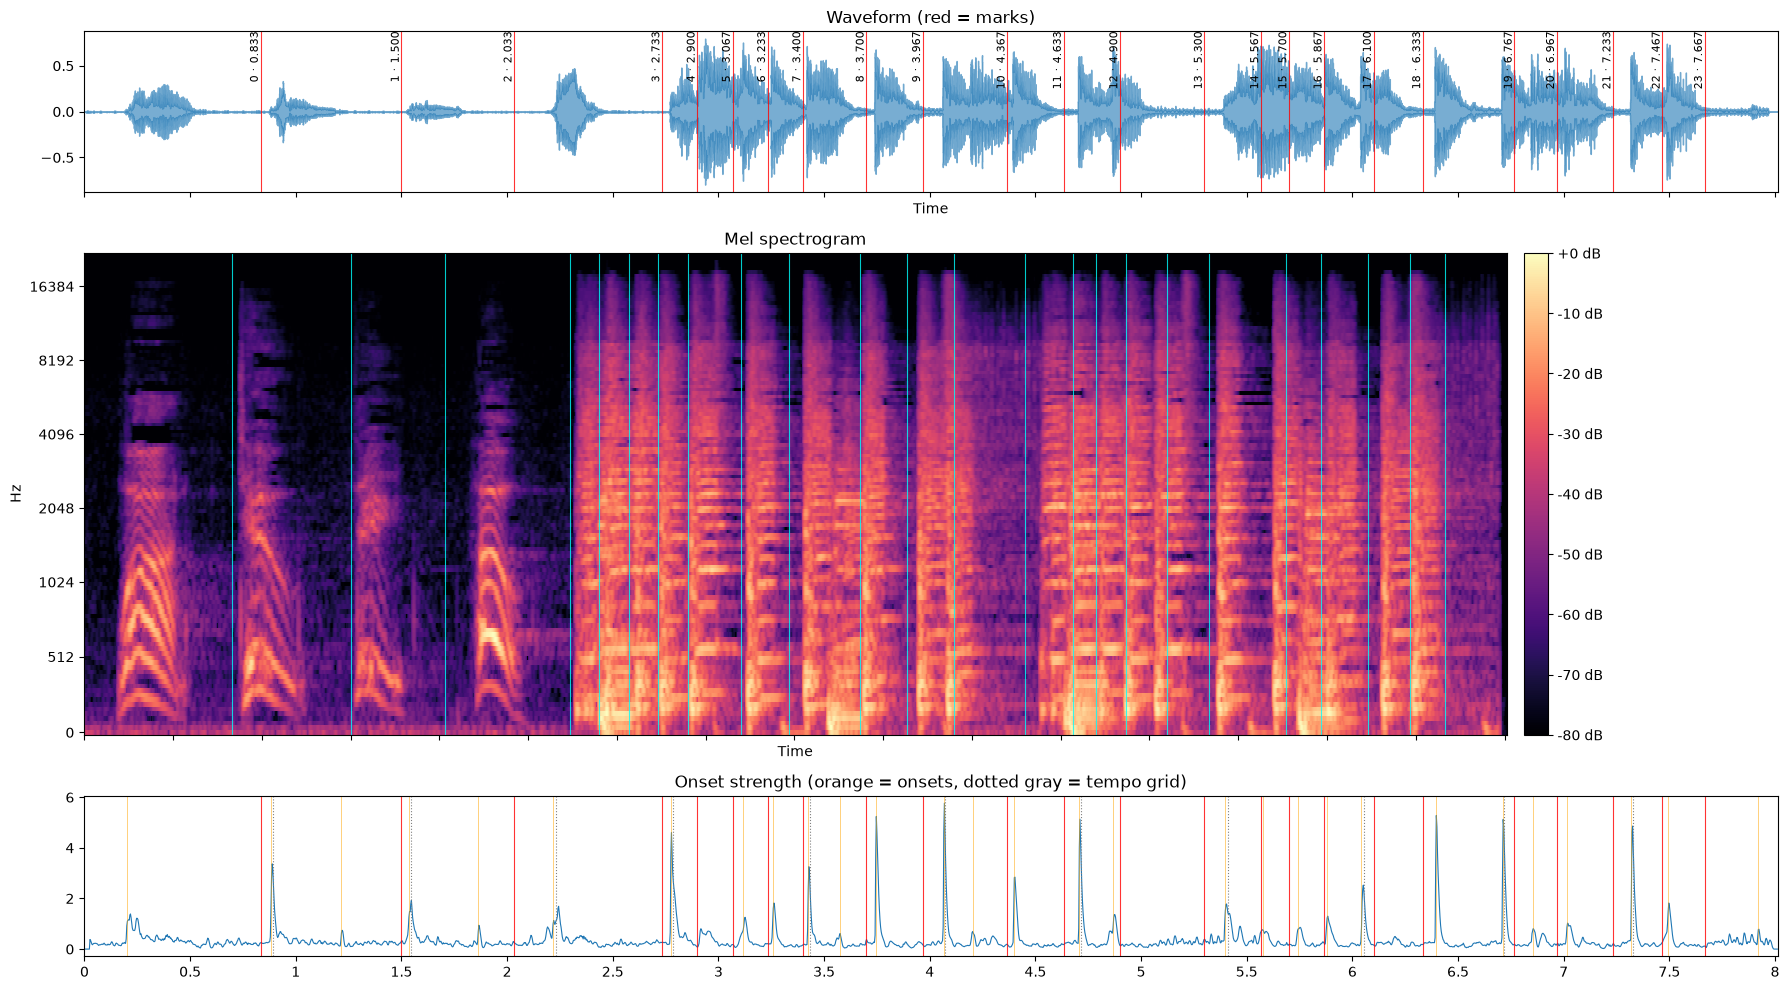

In [3]:
fig, ax = plt.subplots(3, 1, figsize=(18, 10), sharex=True, gridspec_kw=dict(height_ratios=[1, 3, 1]))

librosa.display.waveshow(y, sr=sr, ax=ax[0], alpha=0.6)
S = librosa.power_to_db(librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048, hop_length=HOP, n_mels=128), ref=np.max)
img = librosa.display.specshow(S, sr=sr, hop_length=HOP, x_axis="time", y_axis="mel", ax=ax[1], cmap="magma")
fig.colorbar(img, ax=ax[1], format="%+2.0f dB", pad=0.01)
ax[2].plot(librosa.times_like(onset_env, sr=sr, hop_length=HOP), onset_env, lw=0.8)

for t in beats:
    ax[2].axvline(t, color="gray", lw=0.8, ls=":")
for t in onsets:
    ax[2].axvline(t, color="orange", lw=0.6, alpha=0.6)
for i, t in enumerate(MARKS):
    for a in ax:
        a.axvline(t, color="cyan" if a is ax[1] else "red", lw=0.8, alpha=0.8)
    ax[0].text(t, ax[0].get_ylim()[1], f"{i} · {t:.3f}", rotation=90, va="top", ha="right", fontsize=8)

ax[0].set_title("Waveform (red = marks)"); ax[1].set_title("Mel spectrogram"); ax[2].set_title("Onset strength (orange = onsets, dotted gray = tempo grid)")
ax[2].xaxis.set_major_locator(plt.MultipleLocator(0.5))
plt.tight_layout()

Listen with a click on every detected beat — easiest way to judge if the timings are right.

In [4]:
Audio(y + 0.6 * librosa.clicks(times=MARKS, sr=sr, length=len(y)), rate=sr)

In [5]:
edges = np.r_[0, MARKS, duration]
with open("beats.csv", "w", newline="") as f:
    out = csv.writer(f)
    out.writerow(["segment", "start", "end", "duration"])
    for i, (a, b) in enumerate(zip(edges[:-1], edges[1:])):
        out.writerow([i, f"{a:.3f}", f"{b:.3f}", f"{b - a:.3f}"])
        print(f"{i:3d}  {a:7.3f} → {b:7.3f}  ({b - a:.3f} s)")

  0    0.000 →   0.833  (0.833 s)
  1    0.833 →   1.500  (0.667 s)
  2    1.500 →   2.033  (0.533 s)
  3    2.033 →   2.733  (0.700 s)
  4    2.733 →   2.900  (0.167 s)
  5    2.900 →   3.067  (0.167 s)
  6    3.067 →   3.233  (0.167 s)
  7    3.233 →   3.400  (0.167 s)
  8    3.400 →   3.700  (0.300 s)
  9    3.700 →   3.967  (0.267 s)
 10    3.967 →   4.367  (0.400 s)
 11    4.367 →   4.633  (0.267 s)
 12    4.633 →   4.900  (0.267 s)
 13    4.900 →   5.300  (0.400 s)
 14    5.300 →   5.567  (0.267 s)
 15    5.567 →   5.700  (0.133 s)
 16    5.700 →   5.867  (0.167 s)
 17    5.867 →   6.100  (0.233 s)
 18    6.100 →   6.333  (0.233 s)
 19    6.333 →   6.767  (0.433 s)
 20    6.767 →   6.967  (0.200 s)
 21    6.967 →   7.233  (0.267 s)
 22    7.233 →   7.467  (0.233 s)
 23    7.467 →   7.667  (0.200 s)
 24    7.667 →   8.100  (0.433 s)


Optional: cut the video into one clip per beat (re-encoded with keyframes at each beat so cuts are frame-accurate).

In [6]:
Path("segments").mkdir(exist_ok=True)
for p in Path("segments").glob("*.mp4"):
    p.unlink()
times = ",".join(f"{(round(t * fps) - 0.5) / fps:.4f}" for t in MARKS)  # half a frame early, so each split lands on the nearest frame
subprocess.run(["ffmpeg", "-v", "error", "-y", "-i", VIDEO, "-c:v", "libx264", "-c:a", "aac",
                "-force_key_frames", times, "-f", "segment", "-segment_times", times,
                "-reset_timestamps", "1", "segments/seg_%03d.mp4"], check=True)
sorted(p.name for p in Path("segments").glob("*.mp4"))

['seg_000.mp4',
 'seg_001.mp4',
 'seg_002.mp4',
 'seg_003.mp4',
 'seg_004.mp4',
 'seg_005.mp4',
 'seg_006.mp4',
 'seg_007.mp4',
 'seg_008.mp4',
 'seg_009.mp4',
 'seg_010.mp4',
 'seg_011.mp4',
 'seg_012.mp4',
 'seg_013.mp4',
 'seg_014.mp4',
 'seg_015.mp4',
 'seg_016.mp4',
 'seg_017.mp4',
 'seg_018.mp4',
 'seg_019.mp4',
 'seg_020.mp4',
 'seg_021.mp4',
 'seg_022.mp4',
 'seg_023.mp4',
 'seg_024.mp4']